In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt

from sklearn.gaussian_process.kernels import RBF
from utils import ICMKernel, get_icm_sklearn
from abm.utils import _stack_tasks

In [3]:
rng          = np.random.default_rng(42)
n_per_task   = 5
X_feat       = rng.uniform(-2, 2, size=(n_per_task, 2))  # two spatial dims
X            = np.vstack([np.c_[X_feat, np.zeros(n_per_task)],   # task 0
                         np.c_[X_feat + np.random.normal(loc=0, scale=1, size=X_feat.shape), np.ones (n_per_task)]])   # task 1
rho = 0.6

In [4]:
X_out = np.array([0, 1])
Y_out = np.array([0, 1])
B = rho * (X_out[:, None] != Y_out[None, :]) + (
        X_out[:, None] == Y_out[None, :]
)

In [5]:
B

array([[1. , 0.6],
       [0.6, 1. ]])

In [6]:
xi, yj = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1]), np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

In [7]:
_B = np.array([[1, 0.6], [0.6, 1]])
print(_B)

[[1.  0.6]
 [0.6 1. ]]


In [8]:
B[xi[:, None], yj[None, :]]

array([[1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ]])

In [9]:
_B[xi[:, None], yj[None, :]]

array([[1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [1. , 1. , 1. , 1. , 1. , 0.6, 0.6, 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ],
       [0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. ]])

In [10]:
xi[:, None]

array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1]])

In [11]:
old_k = ICMKernel(length_scale=1.0, rho=0.6)
new_k = get_icm_sklearn(RBF(length_scale=1.0), B)

In [12]:
K_old = old_k(X)
K_new = new_k(X)

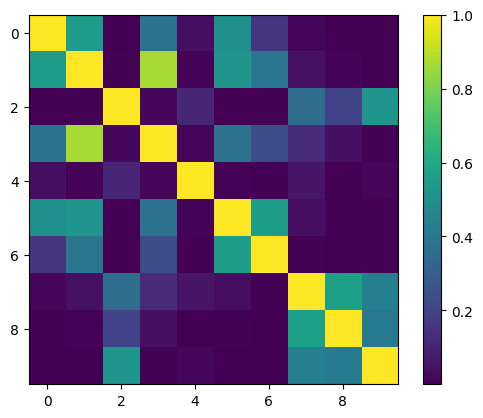

In [13]:
plt.imshow(K_old)
plt.colorbar();

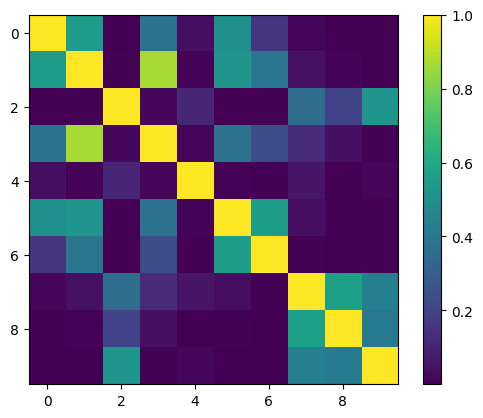

In [14]:
plt.imshow(K_new)
plt.colorbar();

In [15]:
print("max |Δ| =", np.max(np.abs(K_old - K_new)))

max |Δ| = 0.0


## Kernel illustration

In [16]:
from rewards import sample_children_with_corr

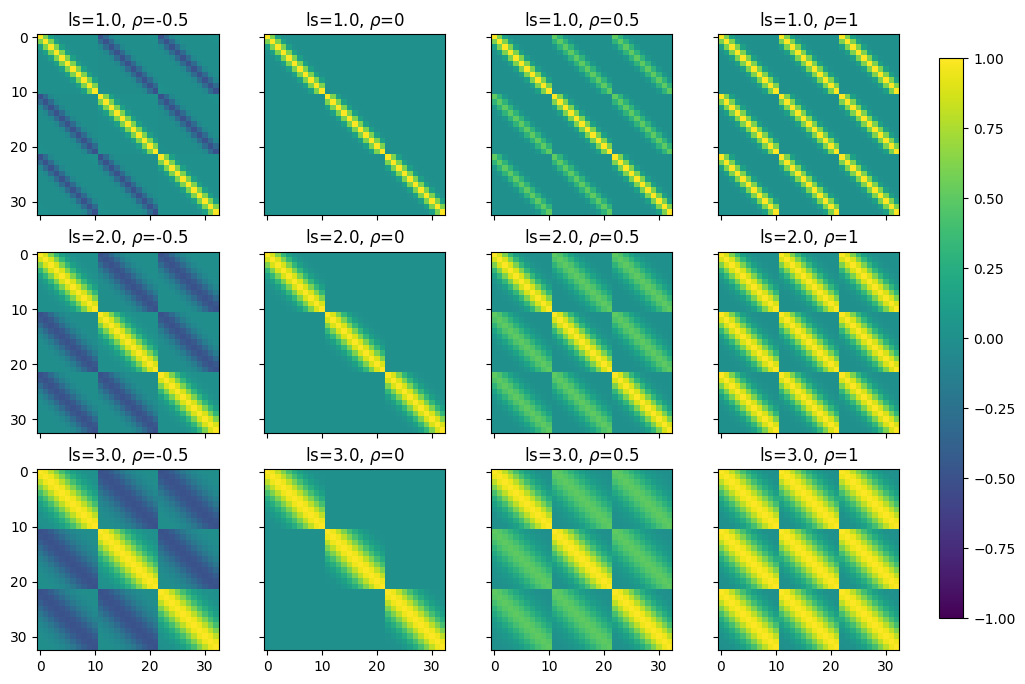

In [44]:
rho_child_child = 0.6
_, child_maps = sample_children_with_corr(
            rng=rng,
            n_children=4,
            length_scale=2.0,
            rho_parent_child=rho_child_child,
            rho_child_child=rho_child_child,
            tol=0.1,
            max_tries=1000,
            grid_size=11
        )

X = np.vstack([np.arange(11), np.zeros(11)]).T
rewards_1 = child_maps[0].mean(axis=1)
rewards_1 =  (rewards_1 - rewards_1.min()) / (rewards_1.max() - rewards_1.min())
rewards_2 = child_maps[1].mean(axis=1)
rewards_2 = (rewards_2 - rewards_2.min()) / (rewards_2.max() - rewards_2.min())
rewards_3 = child_maps[2].mean(axis=1)
rewards_3 = (rewards_3 - rewards_3.min()) / (rewards_3.max() - rewards_3.min())

X_full = _stack_tasks(X, [X, X])

fig, axes = plt.subplots(
    len([1.0, 2.0, 3.0]), len([-0.5, 0, 0.5, 1]), figsize=(12, 8),
    sharex=True, sharey=True
)
for i, ls in enumerate([1.0, 2.0, 3.0]):
    for j, rho in enumerate([-0.5, 0, 0.5, 1]):
        kernel = ICMKernel(length_scale=ls, rho=rho)
        K = kernel(X_full)
        ax = axes[i, j]
        im = ax.imshow(K, vmin=-1, vmax=1)
        ax.set_title(f"ls={ls}, $\\rho$={rho}")
        # ax.axis('off')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
fig.savefig("icm_gp_kernel.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
idxs = [2, 5, 8]
X_obs_private = X[idxs]
y_obs_private = rewards_1[idxs]
idxs = [1, 4, 9]
X_obs_social1 = X[idxs]
y_obs_social1 = rewards_2[idxs]
idxs = [3, 7, 10]
X_obs_social2 = X[idxs]
y_obs_social2 = rewards_3[idxs]

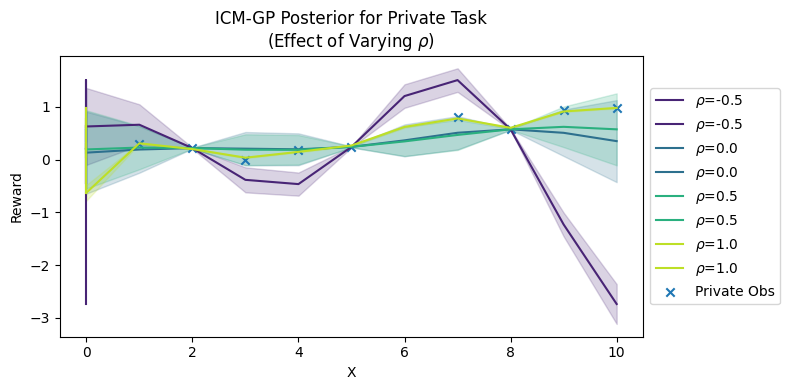

In [19]:
from sklearn.gaussian_process import GaussianProcessRegressor

x_all = _stack_tasks(X_obs_private, [X_obs_social1, X_obs_social2])
y_all = np.concatenate([y_obs_private, y_obs_social1, y_obs_social2])
X_pred = np.column_stack([X, np.zeros(len(X))])

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 4))
rhos = [-0.5, 0.0, 0.5, 1.0]

for i, rho in enumerate(rhos):
    kernel = ICMKernel(length_scale=2.0, rho=rho)
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=False)
    gpr.fit(x_all, y_all)
    mu, std = gpr.predict(X_pred, return_std=True)

    ax.plot(X, mu, label=f"$\\rho$={rho}", color=colors[i])
    ax.fill_between(np.arange(11), mu - std, mu + std, color=colors[i], alpha=0.2)

# Plot private observations
ax.scatter(x_all[:, 0], y_all, # color=x_all[:, 1], 
           marker='x', label="Private Obs")

ax.set_title("ICM-GP Posterior for Private Task\n(Effect of Varying $\\rho$)")
ax.set_xlabel("X")
ax.set_ylabel("Reward")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()


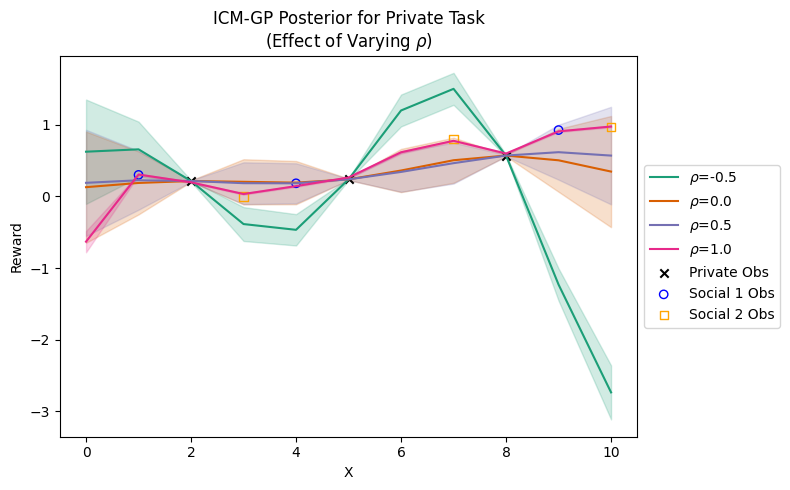

In [20]:
x_all = _stack_tasks(X_obs_private, [X_obs_social1, X_obs_social2])
y_all = np.concatenate([y_obs_private, y_obs_social1, y_obs_social2])

# Predict only for the private task (task index 0)
X_pred = np.column_stack([X, np.zeros(len(X))])

# Prepare plot
fig, ax = plt.subplots(figsize=(8, 5))
# colors = plt.cm.viridis(np.linspace(0.1, 0.9, 4))
colors = plt.get_cmap('Dark2').colors[:4]
rhos = [-0.5, 0.0, 0.5, 1.0]

# GP predictions with ICM for different rho
for i, rho in enumerate(rhos):
    kernel = ICMKernel(length_scale=2.0, rho=rho)
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=False, optimizer=None)
    gpr.fit(x_all, y_all)
    mu, std = gpr.predict(X_pred, return_std=True)

    ax.plot(np.arange(11), mu, label=f"$\\rho$={rho}", color=colors[i])
    ax.fill_between(np.arange(11), mu - std, mu + std, color=colors[i], alpha=0.2)

# Plot private and social observations with distinct markers/colors
plotted_labels = set()
for x, y, task in zip(x_all[:, 0], y_all, x_all[:, 2].astype(int)):
    if task == 0:
        label = "Private Obs" if "Private Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='x', color='black', label=label)
        plotted_labels.add("Private Obs")
    elif task == 1:
        label = "Social 1 Obs" if "Social 1 Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='o', edgecolors='blue', facecolors='none', label=label)
        plotted_labels.add("Social 1 Obs")
    elif task == 2:
        label = "Social 2 Obs" if "Social 2 Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='s', edgecolors='orange', facecolors='none', label=label)
        plotted_labels.add("Social 2 Obs")

# Formatting
ax.set_title("ICM-GP Posterior for Private Task\n(Effect of Varying $\\rho$)")
ax.set_xlabel("X")
ax.set_ylabel("Reward")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
plt.tight_layout()
plt.show()

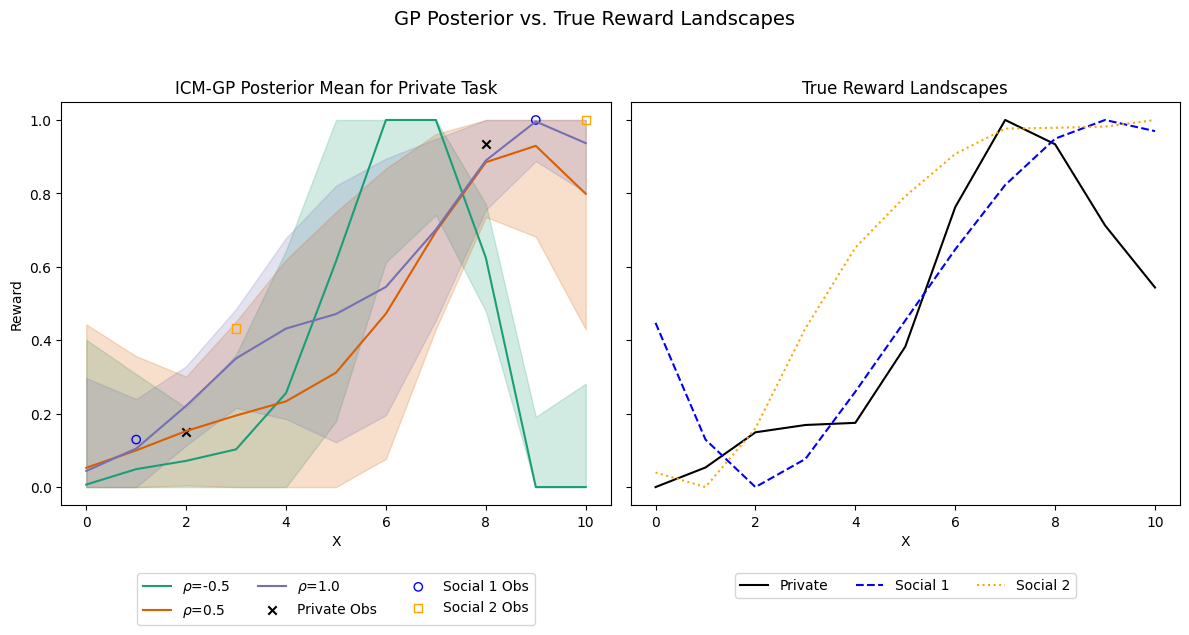

In [46]:
colors = plt.get_cmap('Dark2').colors[:4]
rhos = [-0.5, 0.5, 1.0]
X = np.vstack([np.arange(11), np.zeros(11)]).T

# Normalize helper
normalize = lambda x: (x - np.min(x)) / (np.max(x) - np.min(x))

# Assume rewards_1/2/3 are from child_maps[0:3] or similar
# Normalize to [0, 1]
rewards_1 = normalize(rewards_1)
rewards_2 = normalize(rewards_2)
rewards_3 = normalize(rewards_3)

# Observations
idxs = [2,  8]
X_obs_private = X[idxs]
y_obs_private = rewards_1[idxs]
idxs = [1, 9]
X_obs_social1 = X[idxs]
y_obs_social1 = rewards_2[idxs]
idxs = [3,  10]
X_obs_social2 = X[idxs]
y_obs_social2 = rewards_3[idxs]

# Stack training data
x_all = _stack_tasks(X_obs_private, [X_obs_social1, X_obs_social2])
y_all = np.concatenate([y_obs_private, y_obs_social1, y_obs_social2])

# Predict only for the private task (task index 0)
X_pred = np.column_stack([X, np.zeros(len(X))])

# --- Create two-panel figure ---
fig, axs = plt.subplots(1, 2, figsize=(12, 7), sharey=True)

# ==== LEFT: ICM-GP Posterior Predictions ====
ax = axs[0]
for i, rho in enumerate(rhos):
    kernel = ICMKernel(length_scale=2.0, rho=rho)
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-1, normalize_y=False, optimizer=None)
    gpr.fit(x_all, y_all)
    mu, std = gpr.predict(X_pred, return_std=True)

    # Clip to [0, 1] range to match true rewards
    mu = np.clip(mu, 0, 1)
    std = np.minimum(std, 1)  # optional

    ax.plot(X[:, 0].ravel(), mu, label=f"$\\rho$={rho}", color=colors[i])
    ax.fill_between(X[:, 0].ravel(), np.maximum(0, mu - std / 2), np.minimum(1, mu + std / 2), color=colors[i], alpha=0.2)

# Add observations
plotted_labels = set()
for x, y, task in zip(x_all[:, 0], y_all, x_all[:, 2].astype(int)):
    if task == 0:
        label = "Private Obs" if "Private Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='x', color='black', label=label)
        plotted_labels.add("Private Obs")
    elif task == 1:
        label = "Social 1 Obs" if "Social 1 Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='o', edgecolors='blue', facecolors='none', label=label)
        plotted_labels.add("Social 1 Obs")
    elif task == 2:
        label = "Social 2 Obs" if "Social 2 Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='s', edgecolors='orange', facecolors='none', label=label)
        plotted_labels.add("Social 2 Obs")

ax.set_title("ICM-GP Posterior Mean for Private Task")
ax.set_xlabel("X")
ax.set_ylabel("Reward")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)

# ==== RIGHT: Ground Truth Reward Landscapes ====
ax2 = axs[1]
ax2.plot(X[:, 0].ravel(), rewards_1, color='black', label="Private", linestyle='-')
ax2.plot(X[:, 0].ravel(), rewards_2, color='blue', label="Social 1", linestyle='--')
ax2.plot(X[:, 0].ravel(), rewards_3, color='orange', label="Social 2", linestyle=':')

ax2.set_title("True Reward Landscapes")
ax2.set_xlabel("X")
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)

plt.suptitle("GP Posterior vs. True Reward Landscapes", fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.savefig("icm_gp_vs_true_rewards.png", dpi=300, bbox_inches="tight")
plt.show()